# Задача №3
Обоснованный выбор методов data-driven анализа ВР (ML, DL) и оценка его точности и надежности.

Импорт библиотек

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyod.models.ts_kshape import KShape
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import os
from pyod.models.ts_spectral_residual import SpectralResidual
from pyod.models.ts_lstm import LSTMAD
from sklearn.metrics import mean_absolute_error, mean_squared_error
from mlforecast.lag_transforms import RollingMean, ExpandingMean

# mlforecast
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor


# Импортируем необходимые компоненты из TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



Подготовка данных

In [6]:

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

# Загружаем данные
df = pd.read_csv('data/ETTh1.csv')

# Переименовываем колонки для statsforecast
df = df.rename(columns={
    'date': 'ds',    # колонка с датой → 'ds'
    'OT': 'y'        # целевая переменная → 'y'
})

# Преобразуем дату в datetime
df['ds'] = pd.to_datetime(df['ds'])

if 'df_daily' not in locals():
    df_daily = df[['ds', 'y']].copy()
    df_daily = df_daily.resample('D', on='ds').mean().reset_index()
    df_daily.columns = ['ds', 'y']

## 3.1 Выявление аномалий


Для выявления аномалий будем использовать 3 метода: Kshape, SpectralResidual, LSTMAD

### 3.1.1 Kshape
Kshape - Анализирует форму подпоследовательностей, группируя их в кластеры. Точки, не похожие на остальные, считаются аномалиями.В бенчамарке TSB-AD , этот метод показал одни из лучших результатов при работе с сезонными временными рядами, что идеально подходит для этой задачи.

In [8]:

    # KShape работает с нормализованными данными
# Для детекции аномалий возьмём разность (удалим тренд)
df_diff = df_daily['y'].diff().dropna().values.reshape(-1, 1)

# Нормализуем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_diff)

print(f"\nРазмер данных для обучения: {X_scaled.shape}")


# Параметры KShape:
# - n_clusters: количество кластеров (3-5 обычно достаточно)
# - contamination: доля аномалий в данных (по умолчанию 0.1)
# - random_state: для воспроизводимости результатов

clf_kshape = KShape(
    n_clusters=4,
    window_size=28,# 4 кластера для группировки паттернов
    contamination=0.05,     # ожидаем 5% аномалий
    random_state=42
)

print("\nОбучение KShape...")
clf_kshape.fit(X_scaled)

# Оценка аномальности для каждой точки (чем выше, тем более аномальная)
anomaly_scores = clf_kshape.decision_scores_

# Бинарные метки: 1 = аномалия, 0 = норма
# Порог автоматически определён contamination=0.05
anomaly_labels = clf_kshape.labels_

# Создаём DataFrame с результатами
# Учитываем, что мы теряем первую точку при дифференцировании
results_kshape = df_daily.iloc[1:].copy()
results_kshape['anomaly_score'] = anomaly_scores
results_kshape['is_anomaly'] = anomaly_labels

# Статистика по аномалиям
n_anomalies = results_kshape['is_anomaly'].sum()
print(f"\n Результаты KShape:")
print(f"   Обнаружено аномалий: {n_anomalies} ({n_anomalies/len(results_kshape)*100:.2f}%)")
print(f"   Средний балл аномальности: {anomaly_scores.mean():.4f}")
print(f"   Максимальный балл: {anomaly_scores.max():.4f}")

# Выводим самые аномальные дни
print(f"\n Топ-10 самых аномальных дней:")
top_anomalies = results_kshape.nlargest(10, 'anomaly_score')[['ds', 'y', 'anomaly_score']]
for _, row in top_anomalies.iterrows():
    print(f"   {row['ds'].date()}: температура = {row['y']:.2f}°C, оценка = {row['anomaly_score']:.4f}")


# Silhouette Score оценивает, насколько хорошо данные разделены на кластеры
# Чем выше, тем лучше (максимум 1)
try:
    if len(np.unique(anomaly_labels)) > 1:
        silhouette = silhouette_score(X_scaled, anomaly_labels)
        print(f"\n Silhouette Score: {silhouette:.4f}")

    else:
        print(f"\n Silhouette Score не определён: обнаружен только один кластер")
except Exception as e:
    print(f"\n️ Ошибка расчёта Silhouette: {e}")


Размер данных для обучения: (725, 1)

Обучение KShape...

 Результаты KShape:
   Обнаружено аномалий: 28 (3.86%)
   Средний балл аномальности: 0.6095
   Максимальный балл: 0.6945

 Топ-10 самых аномальных дней:
   2018-01-04: температура = -2.18°C, оценка = 0.6945
   2018-01-05: температура = 1.51°C, оценка = 0.6945
   2018-01-06: температура = 1.09°C, оценка = 0.6945
   2018-01-07: температура = 0.86°C, оценка = 0.6945
   2018-01-08: температура = 0.44°C, оценка = 0.6945
   2018-01-09: температура = 3.04°C, оценка = 0.6945
   2018-01-10: температура = 2.63°C, оценка = 0.6945
   2018-01-11: температура = 3.40°C, оценка = 0.6945
   2018-01-12: температура = 3.17°C, оценка = 0.6945
   2018-01-13: температура = 2.16°C, оценка = 0.6945

 Silhouette Score: -0.1411


Silhouette Score = -0.14 означает, что "аномалии" в среднем ближе к "нормальным" кластерам, чем к своему собственному. Это плохой признак. Аномалии идут подряд (блок 2018-01-04 - 2018-01-13)
Этот блок - просто холодный период зимы, а не аномалия. KShape не смог отличить естественный сезонный паттерн от аномального поведения. Датасет имеет годовой цикл (летом тепло, зимой холодно) Kshape может воспринимать сезонные изменения как аномалии, так же температура масла снижалась на протяжении 2 лет, Kshape не учитывает тренд.

**Вывод: Kshape не подходит для наших данных**

### 3.1.2 SpectralResidual

SpectralResidual - использует преобразование Фурье, чтобы найти аномалии, выделяя остаточную (редкую) часть сигнала

In [10]:

X = df_daily['y'].values.reshape(-1, 1)

# Нормализуем данные (для лучшей сходимости)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nРазмер данных для обучения: {X_scaled.shape}")


# Параметры SpectralResidual:
# - contamination: ожидаемая доля аномалий (5%)
# - window_size: размер окна для анализа (7 дней - недельная сезонность)
# - background_ratio: доля данных для фонового анализа

clf_spectral = SpectralResidual(
    contamination=0.05,          # ожидаем 5% аномалий
    score_window=7,              # размер окна для усреднения спектра (неделя)
    channel_aggregation='max'    # агрегация каналов (для многомерных данных)
)

print("\nОбучение SpectralResidual...")
clf_spectral.fit(X_scaled)


# Оценка аномальности для каждой точки (чем выше, тем более аномальная)
anomaly_scores = clf_spectral.decision_scores_

# Бинарные метки: 1 = аномалия, 0 = норма
anomaly_labels = clf_spectral.labels_

# Создаём DataFrame с результатами
results_spectral = df_daily.copy()
results_spectral['anomaly_score'] = anomaly_scores
results_spectral['is_anomaly'] = anomaly_labels

# Статистика по аномалиям
n_anomalies = results_spectral['is_anomaly'].sum()
print(f"\n Результаты SpectralResidual:")
print(f"   Обнаружено аномалий: {n_anomalies} ({n_anomalies/len(results_spectral)*100:.2f}%)")
print(f"   Средний балл аномальности: {anomaly_scores.mean():.4f}")
print(f"   Максимальный балл: {anomaly_scores.max():.4f}")
print(f"   Порог: {clf_spectral.threshold_:.4f}")

# Выводим самые аномальные дни
print(f"\n Топ-10 самых аномальных дней:")
top_anomalies = results_spectral.nlargest(10, 'anomaly_score')[['ds', 'y', 'anomaly_score']]
for _, row in top_anomalies.iterrows():
    print(f"   {row['ds'].date()}: {row['y']:.2f}°C, оценка = {row['anomaly_score']:.4f}")


# 5. Оценка качества (Silhouette Score)

# Silhouette Score оценивает, насколько хорошо данные разделены на кластеры
try:
    if len(np.unique(anomaly_labels)) > 1:
        silhouette = silhouette_score(X_scaled, anomaly_labels)
        print(f"\n Silhouette Score: {silhouette:.4f}")

    else:
        print(f"\n  Silhouette Score не определён: обнаружен только один кластер")
except Exception as e:
    print(f"\n Ошибка расчёта Silhouette: {e}")



Размер данных для обучения: (726, 1)

Обучение SpectralResidual...

 Результаты SpectralResidual:
   Обнаружено аномалий: 37 (5.10%)
   Средний балл аномальности: 0.5027
   Максимальный балл: 0.8572
   Порог: 0.7768

 Топ-10 самых аномальных дней:
   2016-07-01: 21.07°C, оценка = 0.8572
   2016-07-30: 41.44°C, оценка = 0.8459
   2016-07-13: 36.04°C, оценка = 0.8339
   2016-07-12: 35.86°C, оценка = 0.8312
   2016-07-05: 30.10°C, оценка = 0.8302
   2016-07-24: 40.57°C, оценка = 0.8229
   2016-07-07: 31.20°C, оценка = 0.8216
   2016-08-19: 35.11°C, оценка = 0.8200
   2016-07-25: 41.28°C, оценка = 0.8189
   2016-07-03: 26.63°C, оценка = 0.8172

 Silhouette Score: 0.5265


SpectralResidual показал хорошее качество - Silhouette Score = 0.5265 (> 0.5), что означает отличное разделение на нормальные и аномальные точки.

Построим графики для визуализации



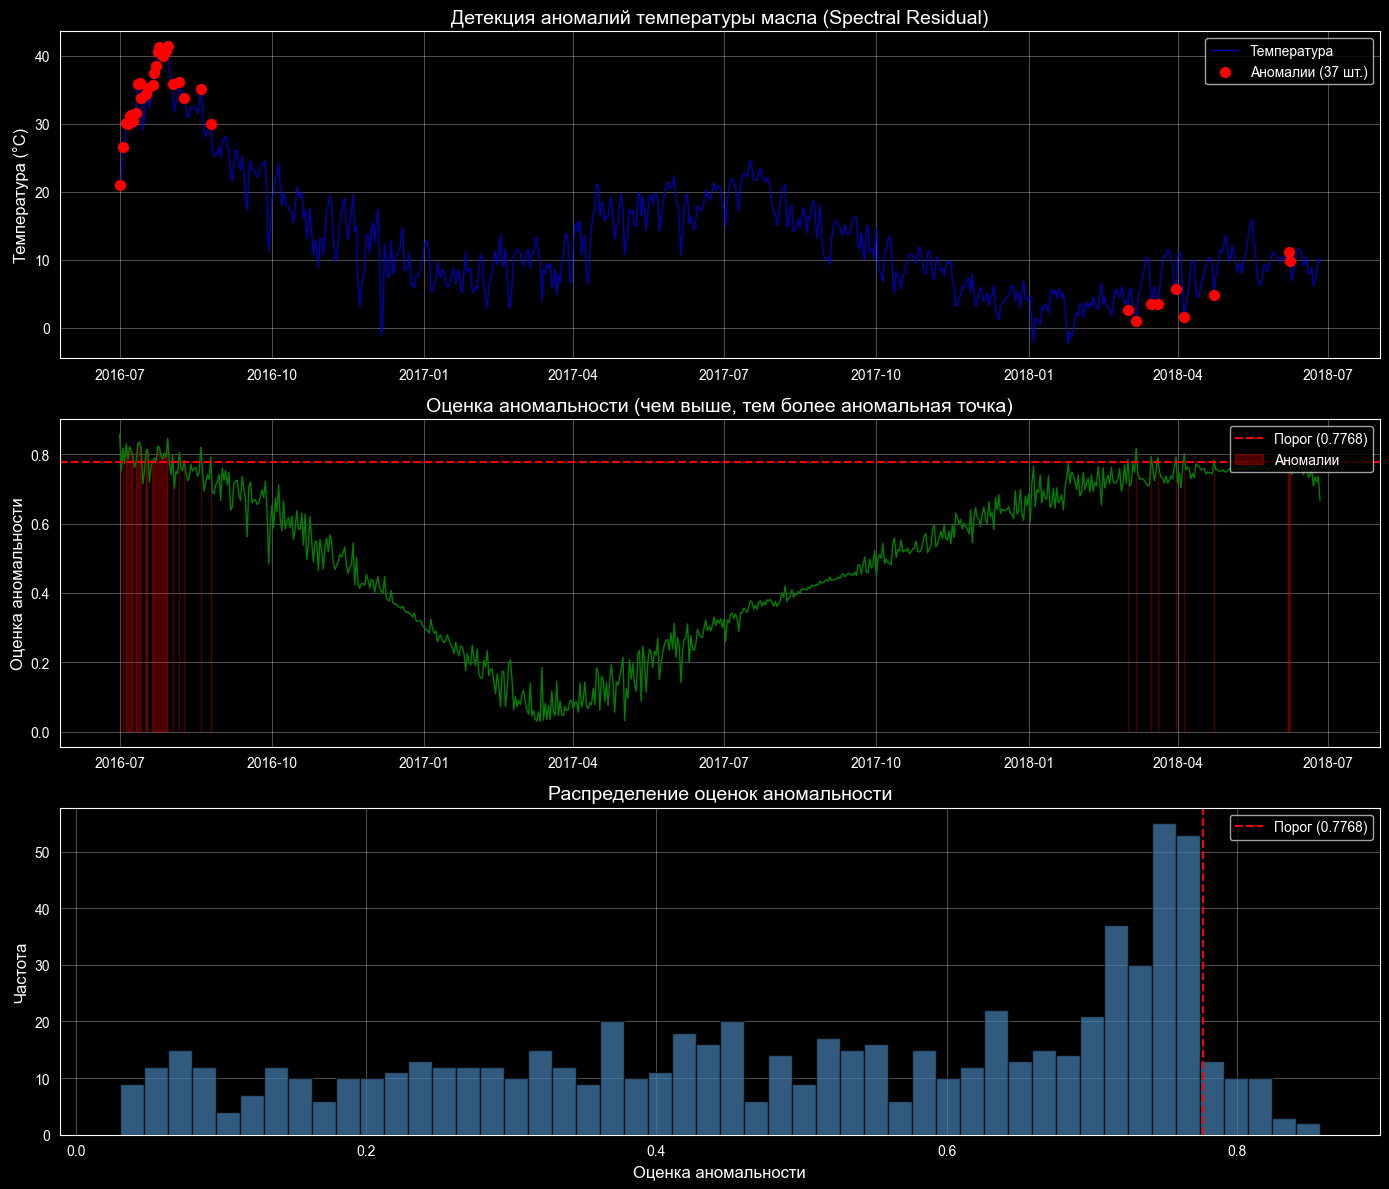

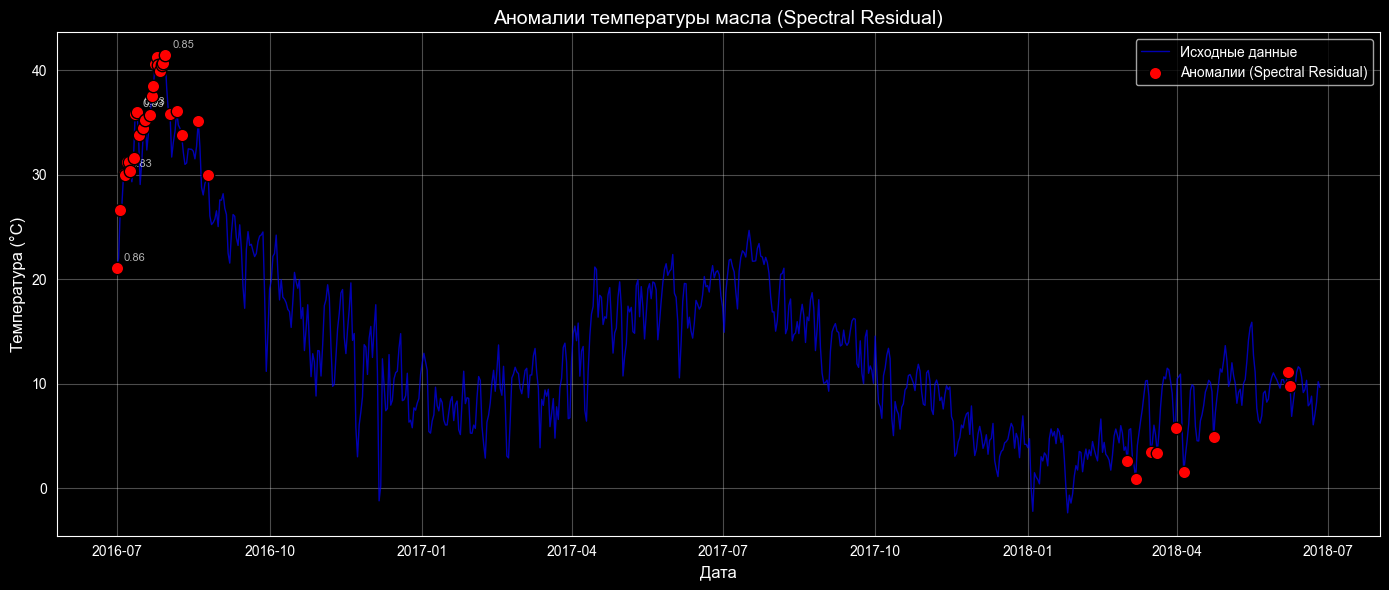

Метод SpectralResidual обнаружил 37 аномалий (5.10% от всех данных)
Silhouette Score: 0.5265


In [13]:

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# График 1: Временной ряд с выделением аномалий
ax1 = axes[0]
ax1.plot(results_spectral['ds'], results_spectral['y'],
         color='blue', linewidth=1, alpha=0.7, label='Температура')

# Выделяем аномалии
anomalies = results_spectral[results_spectral['is_anomaly'] == 1]
if not anomalies.empty:
    ax1.scatter(anomalies['ds'], anomalies['y'],
                color='red', s=50, zorder=5, label=f'Аномалии ({n_anomalies} шт.)')

ax1.set_title('Детекция аномалий температуры масла (Spectral Residual)', fontsize=14)
ax1.set_ylabel('Температура (°C)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# График 2: Оценка аномальности
ax2 = axes[1]
ax2.plot(results_spectral['ds'], results_spectral['anomaly_score'],
         color='green', linewidth=1)
ax2.axhline(y=clf_spectral.threshold_, color='red', linestyle='--',
            label=f'Порог ({clf_spectral.threshold_:.4f})')
ax2.fill_between(results_spectral['ds'], 0, results_spectral['anomaly_score'],
                  where=results_spectral['anomaly_score'] > clf_spectral.threshold_,
                  color='red', alpha=0.3, label='Аномалии')
ax2.set_title('Оценка аномальности (чем выше, тем более аномальная точка)', fontsize=14)
ax2.set_ylabel('Оценка аномальности', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# График 3: Распределение оценок аномальности (гистограмма)
ax3 = axes[2]
ax3.hist(results_spectral['anomaly_score'], bins=50, edgecolor='black',
         color='steelblue', alpha=0.7)
ax3.axvline(x=clf_spectral.threshold_, color='red', linestyle='--',
            label=f'Порог ({clf_spectral.threshold_:.4f})')
ax3.set_title('Распределение оценок аномальности', fontsize=14)
ax3.set_xlabel('Оценка аномальности', fontsize=12)
ax3.set_ylabel('Частота', fontsize=12)
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


if not anomalies.empty:
    fig, ax = plt.subplots(figsize=(14, 6))

    # Исходный ряд
    ax.plot(results_spectral['ds'], results_spectral['y'],
            color='blue', linewidth=1, alpha=0.7, label='Исходные данные')

    # Выделяем аномалии
    ax.scatter(anomalies['ds'], anomalies['y'],
               color='red', s=80, zorder=5, edgecolor='black',
               label=f'Аномалии (Spectral Residual)')

    # Подписываем аномалии (только топ-5)
    for _, row in anomalies.nlargest(5, 'anomaly_score').iterrows():
        ax.annotate(f"{row['anomaly_score']:.2f}",
                    (row['ds'], row['y']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.7)

    ax.set_title('Аномалии температуры масла (Spectral Residual)', fontsize=14)
    ax.set_xlabel('Дата', fontsize=12)
    ax.set_ylabel('Температура (°C)', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()



print(f"Метод SpectralResidual обнаружил {n_anomalies} аномалий ({n_anomalies/len(results_spectral)*100:.2f}% от всех данных)")
if 'silhouette' in locals() and silhouette is not None:
    print(f"Silhouette Score: {silhouette:.4f}")



### 3.1.3 LSTMAD
Обучает LSTM предсказывать следующий шаг. Если прогноз сильно отличается от реальности, точка считается аномалией

In [19]:

X = df_daily['y'].values.reshape(-1, 1)

# Нормализуем данные (для лучшей сходимости)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nРазмер данных для обучения: {X_scaled.shape}")

# 3. ОБУЧЕНИЕ LSTMAD


# Параметры LSTMAD согласно документации PyOD:
# - contamination: ожидаемая доля аномалий (5%)
# - hidden_neurons: количество нейронов в скрытом слое LSTM (по умолчанию 32)
# - epochs: количество эпох обучения (по умолчанию 50)
# - verbose: уровень детализации (0 - без вывода, 1 - с выводом)
# - random_state: для воспроизводимости результатов

clf_lstm = LSTMAD(
    window_size=14,         # 14 дней → 2 недели (баланс между кратко- и долгосрочными паттернами)
    hidden_size=16,         # 16 нейронов (меньше, чтобы не переобучаться)
    n_layers=1,             # 1 слой LSTM (проще, быстрее, меньше риска переобучения)
    epochs=100,             # 100 эпох (больше шансов на сходимость)
    lr=5e-4,                # скорость обучения 0.0005 (стабильнее)
    batch_size=64,          # больший батч для стабильности
    contamination=0.05,     # 5% аномалий
)     # ожидаем 5% аномалий

print("\nОбучение LSTMAD...")

clf_lstm.fit(X_scaled)


# Оценка аномальности для каждой точки (чем выше, тем более аномальная)
anomaly_scores = clf_lstm.decision_scores_

# Бинарные метки: 1 = аномалия, 0 = норма
anomaly_labels = clf_lstm.labels_

# Создаём DataFrame с результатами
results_lstm = df_daily.copy()
results_lstm['anomaly_score'] = anomaly_scores
results_lstm['is_anomaly'] = anomaly_labels

# Статистика по аномалиям
n_anomalies = results_lstm['is_anomaly'].sum()
print(f"\n Результаты LSTMAD:")
print(f"   Обнаружено аномалий: {n_anomalies} ({n_anomalies/len(results_lstm)*100:.2f}%)")
print(f"   Средний балл аномальности: {anomaly_scores.mean():.4f}")
print(f"   Максимальный балл: {anomaly_scores.max():.4f}")
print(f"   Порог: {clf_lstm.threshold_:.4f}")

# Выводим самые аномальные дни
print(f"\n Топ-10 самых аномальных дней:")
top_anomalies = results_lstm.nlargest(10, 'anomaly_score')[['ds', 'y', 'anomaly_score']]
for _, row in top_anomalies.iterrows():
    print(f"   {row['ds'].date()}: {row['y']:.2f}°C, оценка = {row['anomaly_score']:.4f}")


# 5. ОЦЕНКА КАЧЕСТВА (Silhouette Score)

try:
    if len(np.unique(anomaly_labels)) > 1:
        silhouette = silhouette_score(X_scaled, anomaly_labels)
        print(f"\n Silhouette Score: {silhouette:.4f}")

    else:
        print(f"\n Silhouette Score не определён: обнаружен только один кластер")
except Exception as e:
    print(f"\n Ошибка расчёта Silhouette: {e}")




Размер данных для обучения: (726, 1)

Обучение LSTMAD...

 Результаты LSTMAD:
   Обнаружено аномалий: 36 (4.96%)
   Средний балл аномальности: 1.0443
   Максимальный балл: 35.2417
   Порог: 3.3673

 Топ-10 самых аномальных дней:
   2016-12-06: -1.18°C, оценка = 35.2417
   2016-09-29: 11.20°C, оценка = 16.8900
   2016-11-22: 5.82°C, оценка = 15.0201
   2016-11-23: 3.03°C, оценка = 13.1261
   2016-12-07: 0.25°C, оценка = 11.9941
   2017-03-13: 3.89°C, оценка = 8.1608
   2017-06-05: 10.58°C, оценка = 8.1565
   2018-04-05: 1.59°C, оценка = 7.9068
   2017-02-21: 3.10°C, оценка = 7.2192
   2017-05-02: 10.76°C, оценка = 6.8974

 Silhouette Score: 0.1181


Результат чуть лучше случайного, попробуем удалить тренд в данных и создать сетку параметров для поиска лучших

In [21]:

#  удаляем тренд для лучшей работы LSTM
from scipy import signal
detrended = signal.detrend(df_daily['y'].values)
X = detrended.reshape(-1, 1)

# Нормализуем
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nРазмер данных: {X_scaled.shape}")

# 3. перебор параметров (автоматический поиск лучших)


# Сетка параметров для перебора
param_grid = [
    # (window_size, hidden_size, n_layers, epochs, lr, batch_size)
    (7, 8, 1, 80, 1e-4, 32),    # маленькое окно, маленькая сеть
    (7, 16, 1, 100, 5e-5, 64),   # маленькое окно, средняя сеть
    (14, 8, 1, 100, 1e-4, 32),   # среднее окно, маленькая сеть
    (14, 16, 1, 120, 5e-5, 64),  # среднее окно, средняя сеть
    (21, 8, 1, 150, 1e-5, 64),   # большое окно, маленькая сеть
]

best_silhouette = -1
best_params = None
best_labels = None
best_scores = None

print("\nПеребор параметров LSTMAD...")

for window_size, hidden_size, n_layers, epochs, lr, batch_size in param_grid:
    print(f"\nТестируем: window={window_size}, hidden={hidden_size}, layers={n_layers}, epochs={epochs}, lr={lr}, batch={batch_size}")

    try:
        clf = LSTMAD(
            window_size=window_size,
            hidden_size=hidden_size,
            n_layers=n_layers,
            epochs=epochs,
            lr=lr,
            batch_size=batch_size,
            contamination=0.05,
        )

        clf.fit(X_scaled)
        labels = clf.labels_
        scores = clf.decision_scores_

        if len(np.unique(labels)) > 1:
            sil = silhouette_score(X_scaled, labels)
            print(f"   Silhouette Score: {sil:.4f}, аномалий: {labels.sum()}")

            if sil > best_silhouette:
                best_silhouette = sil
                best_params = (window_size, hidden_size, n_layers, epochs, lr, batch_size)
                best_labels = labels
                best_scores = scores
        else:
            print(f"    Только один кластер")

    except Exception as e:
        print(f"    Ошибка: {str(e)[:50]}")


print("Лучшие параметры")
print("=" * 60)
if best_params:
    print(f"window_size={best_params[0]}, hidden_size={best_params[1]}, n_layers={best_params[2]}")
    print(f"epochs={best_params[3]}, lr={best_params[4]}, batch_size={best_params[5]}")
    print(f"Silhouette Score: {best_silhouette:.4f}")
else:
    print("Не удалось найти хорошие параметры")


# 4. Обучение с лучшими параметрами


if best_params:
    clf_best = LSTMAD(
        window_size=best_params[0],
        hidden_size=best_params[1],
        n_layers=best_params[2],
        epochs=best_params[3],
        lr=best_params[4],
        batch_size=best_params[5],
        contamination=0.05,
    )

    clf_best.fit(X_scaled)
    anomaly_scores = clf_best.decision_scores_
    anomaly_labels = clf_best.labels_

    results_lstm = df_daily.copy()
    results_lstm['anomaly_score'] = anomaly_scores
    results_lstm['is_anomaly'] = anomaly_labels

    n_anomalies = results_lstm['is_anomaly'].sum()
    print(f"\n Финальные результаты:")
    print(f"   Обнаружено аномалий: {n_anomalies} ({n_anomalies/len(results_lstm)*100:.2f}%)")




Размер данных: (726, 1)

Перебор параметров LSTMAD...

Тестируем: window=7, hidden=8, layers=1, epochs=80, lr=0.0001, batch=32
   Silhouette Score: 0.4622, аномалий: 36

Тестируем: window=7, hidden=16, layers=1, epochs=100, lr=5e-05, batch=64
   Silhouette Score: 0.5165, аномалий: 36

Тестируем: window=14, hidden=8, layers=1, epochs=100, lr=0.0001, batch=32
   Silhouette Score: 0.4705, аномалий: 36

Тестируем: window=14, hidden=16, layers=1, epochs=120, lr=5e-05, batch=64
   Silhouette Score: 0.4967, аномалий: 36

Тестируем: window=21, hidden=8, layers=1, epochs=150, lr=1e-05, batch=64
   Silhouette Score: 0.5207, аномалий: 36
Лучшие параметры
window_size=21, hidden_size=8, n_layers=1
epochs=150, lr=1e-05, batch_size=64
Silhouette Score: 0.5207

 Финальные результаты:
   Обнаружено аномалий: 36 (4.96%)


этот результат уже намного лучше, построим графики для визуализации

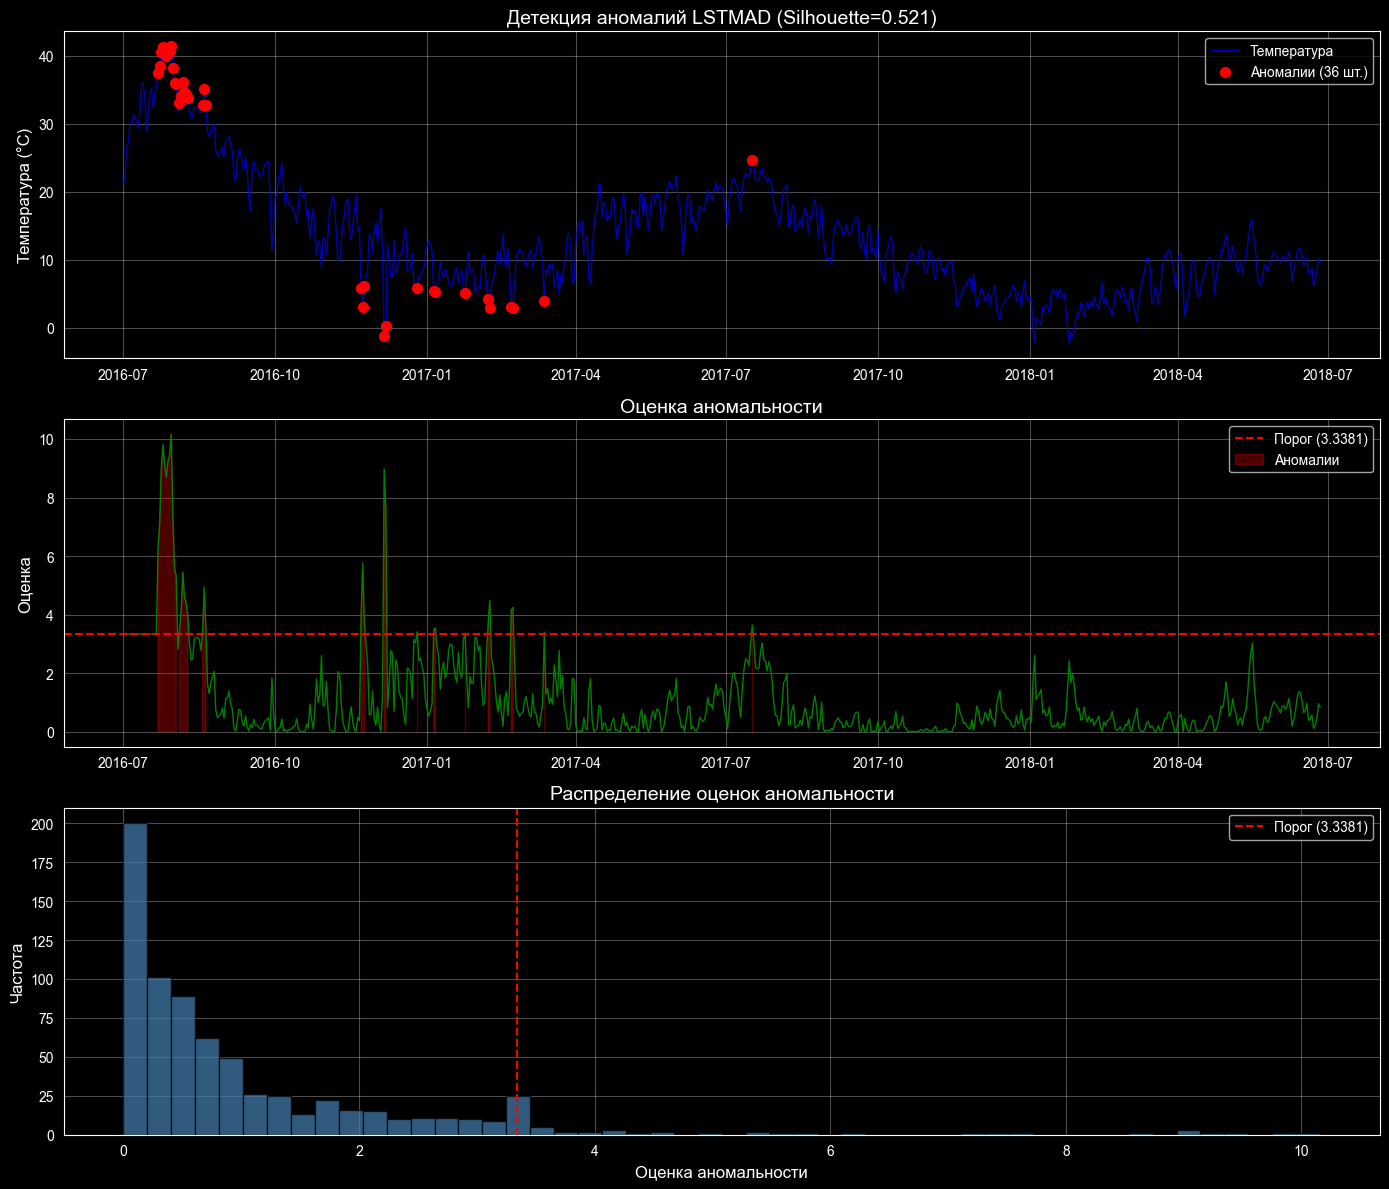

In [22]:

    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    # График 1: Временной ряд с аномалиями
    ax1 = axes[0]
    ax1.plot(results_lstm['ds'], results_lstm['y'],
             color='blue', linewidth=1, alpha=0.7, label='Температура')

    anomalies = results_lstm[results_lstm['is_anomaly'] == 1]
    if not anomalies.empty:
        ax1.scatter(anomalies['ds'], anomalies['y'],
                    color='red', s=50, zorder=5, label=f'Аномалии ({n_anomalies} шт.)')

    ax1.set_title(f'Детекция аномалий LSTMAD (Silhouette={best_silhouette:.3f})', fontsize=14)
    ax1.set_ylabel('Температура (°C)', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # График 2: Оценка аномальности
    ax2 = axes[1]
    ax2.plot(results_lstm['ds'], results_lstm['anomaly_score'],
             color='green', linewidth=1)
    ax2.axhline(y=clf_best.threshold_, color='red', linestyle='--',
                label=f'Порог ({clf_best.threshold_:.4f})')
    ax2.fill_between(results_lstm['ds'], 0, results_lstm['anomaly_score'],
                      where=results_lstm['anomaly_score'] > clf_best.threshold_,
                      color='red', alpha=0.3, label='Аномалии')
    ax2.set_title('Оценка аномальности', fontsize=14)
    ax2.set_ylabel('Оценка', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # График 3: Гистограмма
    ax3 = axes[2]
    ax3.hist(results_lstm['anomaly_score'], bins=50, edgecolor='black',
             color='steelblue', alpha=0.7)
    ax3.axvline(x=clf_best.threshold_, color='red', linestyle='--',
                label=f'Порог ({clf_best.threshold_:.4f})')
    ax3.set_title('Распределение оценок аномальности', fontsize=14)
    ax3.set_xlabel('Оценка аномальности', fontsize=12)
    ax3.set_ylabel('Частота', fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

**Вывод: SpectralResidual и LSTMAD показали хорошие результаты, Kshape оказался неэффективен для наших данных**

## 3.1 Прогнозирование на основе моделей машинного обучения

в отличие от статистчиеских моделей, ML модели предсказывают  будущее по набору признаков (features). Модель не "понимает", что это временной ряд, она просто видит таблицу: сегодняшняя температура зависит от температуры 7 дней назад, дня недели, месяца и так далее.

Для обучения возьмем 3 разных модели: LightGBM, XGBoost, Random Forest и сравним их показатели.

Первые строки подготовленных данных:
          ds          y unique_id
0 2016-07-01  21.071833  oil_temp
1 2016-07-02  22.039208  oil_temp
2 2016-07-03  26.626375  oil_temp
3 2016-07-04  27.162666  oil_temp
4 2016-07-05  30.102583  oil_temp

--- Запуск кросс-валидации ML моделей ---
Кросс-валидация завершена.

--- Оценка качества ML моделей ---
Оцененные модели: ['LGBMRegressor', 'XGBRegressor', 'RandomForestRegressor']
LGBMRegressor: MAE=1.9476°C, RMSE=2.6295°C
XGBRegressor: MAE=2.0323°C, RMSE=2.5721°C
RandomForestRegressor: MAE=1.8746°C, RMSE=2.5689°C


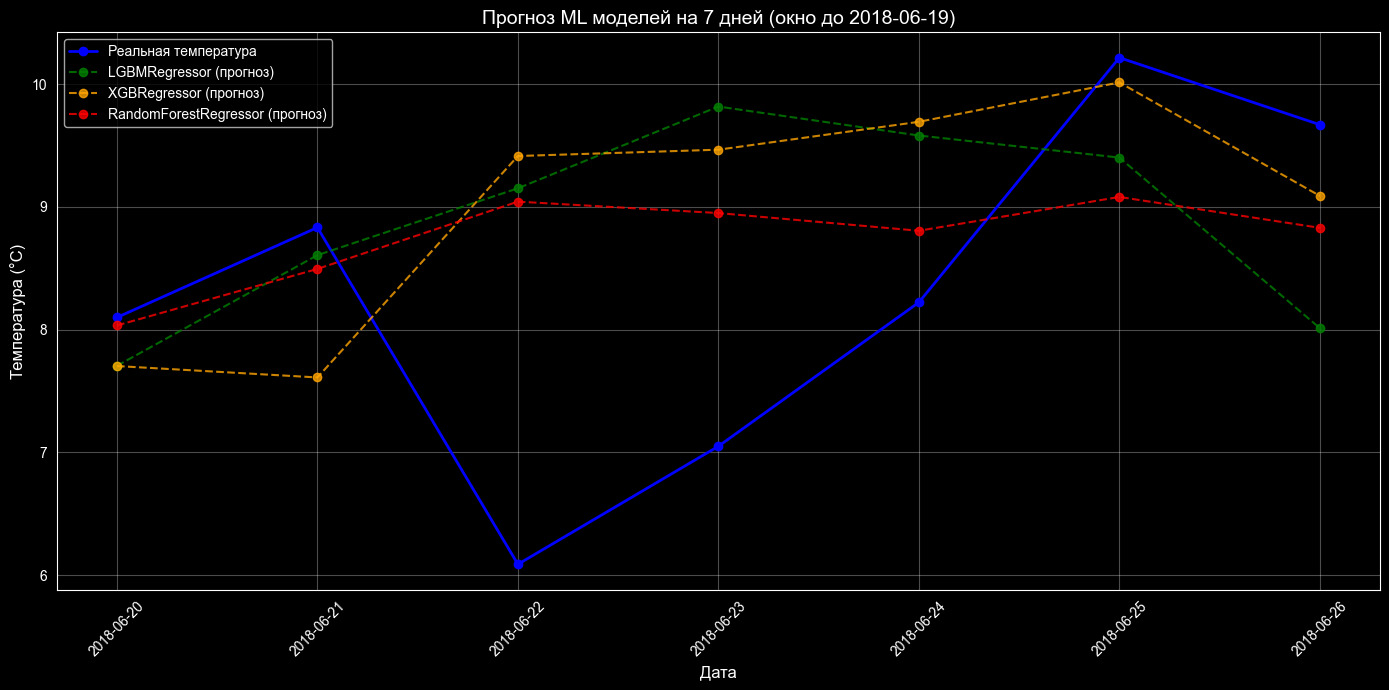

In [14]:

# 1. Подготовка данных
# Используем наши дневные данные (df_daily)
# Добавляем колонку unique_id. Для одного ряда это может быть любая константа.
df_ml = df_daily.copy()
df_ml['unique_id'] = 'oil_temp'
df_ml = df_ml.rename(columns={'ds': 'ds', 'y': 'y'}) # Убедимся, что названия колонок стандартные

print("Первые строки подготовленных данных:")
print(df_ml.head())

#  горизонт прогнозированиякак и в задании №2, для недели
HORIZON = 7

# ------------------------------
# 2. Определение Feature Engineering
# ------------------------------
# Это самый важный шаг! Мы создаем признаки, которые модель будет использовать для обучения.
# - lags: значения целевой переменной за предыдущие дни (1, 7, 14, 21, 28 дней назад) [citation:1]
# - lag_transforms: скользящие статистики по лагам (например, скользящее среднее за 7 дней)
# - date_features: извлекаем признаки из даты (день недели, месяц)
# - target_transforms: преобразуем целевую переменную. Differences([1]) делает ряд стационарным (первая разность), как мы это делали для ARIMA [citation:1].

fcst = MLForecast(
    models=[
        LGBMRegressor(random_state=42, verbosity=-1),
        XGBRegressor(random_state=42, verbosity=0),
        RandomForestRegressor(random_state=42)
    ],
    freq='D',
    lags=[1, 7, 14, 21, 28],
    lag_transforms={
        1: [RollingMean(window_size=7)],      # Rolling mean of lag 1 over 7 days
        7: [RollingMean(window_size=14)],     # Rolling mean of lag 7 over 14 days
        14: [RollingMean(window_size=7)],     # Rolling mean of lag 14 over 7 days
    },
    date_features=['dayofweek', 'month'],
    target_transforms=[Differences([1])],
    num_threads=6,
)



# 3. Кросс-валидация

print("\n--- Запуск кросс-валидации ML моделей ---")
# Метод cross_validation сам разобьет данные на обучающие и тестовые окна.
# n_windows=5 означает, что мы проверим модели на 5 различных периодах.
cv_results_ml = fcst.cross_validation(
    df=df_ml,
    h=HORIZON,
    step_size=HORIZON, # Окна не перекрываются
    n_windows=10,       # Проверяем на 5 последних неделях
)

print("Кросс-валидация завершена.")


# 4. Оценка и сравнение моделей
print("\n--- Оценка качества ML моделей ---")
# Получаем список названий обученных моделей
model_names = [model_name for model_name in cv_results_ml.columns if model_name not in ['unique_id', 'ds', 'y', 'cutoff']]
print(f"Оцененные модели: {model_names}")

results_ml = {}

for model_name in model_names:
    # Рассчитываем MAE и RMSE для каждой модели
    mae = mean_absolute_error(cv_results_ml['y'], cv_results_ml[model_name])
    rmse = np.sqrt(mean_squared_error(cv_results_ml['y'], cv_results_ml[model_name]))
    results_ml[model_name] = {'MAE': mae, 'RMSE': rmse}
    print(f"{model_name}: MAE={mae:.4f}°C, RMSE={rmse:.4f}°C")


# 5. Сравнение с лучшей статистической моделью
# ------------------------------
# Здесь mae_auto_arima — это значение MAE лучшей модели из Задания №2 (например, AutoARIMA)
'''
if 'mae_auto_arima' in locals():
    print("\n--- Сравнение ML моделей с лучшей статистической моделью (AutoARIMA) ---")
    for model_name in results_ml:
        improvement = ((mae_auto_arima - results_ml[model_name]['MAE']) / mae_auto_arima) * 100
        print(f"{model_name} лучше AutoARIMA на {improvement:.2f}% (MAE={results_ml[model_name]['MAE']:.4f} vs {mae_auto_arima:.4f})")
'''
# ------------------------------
# 6. Визуализация результатов
# ------------------------------
# Возьмем последнее окно для наглядного сравнения прогнозов
last_cutoff = cv_results_ml['cutoff'].max()
last_window = cv_results_ml[cv_results_ml['cutoff'] == last_cutoff]

plt.figure(figsize=(14, 7))
plt.plot(last_window['ds'], last_window['y'], 'bo-', label='Реальная температура', linewidth=2)

colors = {'LGBMRegressor': 'green', 'XGBRegressor': 'orange', 'RandomForestRegressor': 'red'}
for model_name in model_names:
    plt.plot(last_window['ds'], last_window[model_name], 'o--', label=f'{model_name} (прогноз)', color=colors.get(model_name, 'gray'), alpha=0.8)

plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.title(f'Прогноз ML моделей на 7 дней (окно до {last_cutoff.date()})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from mlforecast.lag_transforms import RollingMean
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor



HORIZON = 7

# Базовое определение признаков для MLForecast
# Важно: lags и lag_transforms мы не будем трогать при подборе гиперпараметров моделей.
def get_base_forecaster(models):
    """Создает базовый MLForecast объект с заданными моделями."""
    return MLForecast(
        models=models,
        freq='D',
        lags=[1, 7, 14, 21, 28],
        lag_transforms={
            1: [RollingMean(window_size=7)],
            7: [RollingMean(window_size=14)],
            14: [RollingMean(window_size=7)],
        },
        date_features=['dayofweek', 'month'],
        target_transforms=[Differences([1])],
        num_threads=6,
    )

# --- 2. Функции для оптимизации каждой модели ---

# Целевая функция для Optuna
def objective_lgbm(trial, df, horizon):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbosity': -1
    }
    model = LGBMRegressor(**params)
    fcst = get_base_forecaster([model])
    cv_df = fcst.cross_validation(df=df, h=horizon, step_size=horizon, n_windows=5)
    return mean_absolute_error(cv_df['y'], cv_df['LGBMRegressor'])


def objective_xgb(trial, df, horizon):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbosity': 0
    }
    model = XGBRegressor(**params)
    fcst = get_base_forecaster([model])
    cv_df = fcst.cross_validation(df=df, h=horizon, step_size=horizon, n_windows=5)
    return mean_absolute_error(cv_df['y'], cv_df['XGBRegressor'])


def objective_rf(trial, df, horizon):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.8]),
        'random_state': 42,
        'n_jobs': -1
    }
    model = RandomForestRegressor(**params)
    fcst = get_base_forecaster([model])
    cv_df = fcst.cross_validation(df=df, h=horizon, step_size=horizon, n_windows=5)
    return mean_absolute_error(cv_df['y'], cv_df['RandomForestRegressor'])


# --- 3. Запуск оптимизации и сбор результатов ---
print("\n---Подбор гиперпараметров  ---")

# LightGBM
print("\n Оптимизация LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(lambda trial: objective_lgbm(trial, df_ml, HORIZON), n_trials=30, show_progress_bar=True)
best_params_lgbm = study_lgbm.best_params
print(f"Лучшие параметры LightGBM: {best_params_lgbm}")

# XGBoost
print("\n Оптимизация XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(lambda trial: objective_xgb(trial, df_ml, HORIZON), n_trials=30, show_progress_bar=True)
best_params_xgb = study_xgb.best_params
print(f"Лучшие параметры XGBoost: {best_params_xgb}")

# Random Forest
print("\n Оптимизация Random Forest...")
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(lambda trial: objective_rf(trial, df_ml, HORIZON), n_trials=30, show_progress_bar=True)
best_params_rf = study_rf.best_params
print(f"Лучшие параметры Random Forest: {best_params_rf}")

# --- 4. Оценка финальных моделей с лучшими параметрами ---
print("\n--- Оценка моделей с лучшими параметрами ---")

# Создаем модели с лучшими параметрами
best_lgbm = LGBMRegressor(**best_params_lgbm, verbosity=-1)
best_xgb = XGBRegressor(**best_params_xgb, verbosity=0)
best_rf = RandomForestRegressor(**best_params_rf)

# Собираем их в один MLForecast объект для финальной оценки
final_models = [best_lgbm, best_xgb, best_rf]
final_forecaster = get_base_forecaster(final_models)

# Проводим кросс-валидацию для финальной оценки
final_cv_results = final_forecaster.cross_validation(df=df_ml, h=HORIZON, step_size=HORIZON, n_windows=5)

# Выводим метрики
model_names = ['LGBMRegressor', 'XGBRegressor', 'RandomForestRegressor']
improved_results = {}

for model_name in model_names:
    mae = mean_absolute_error(final_cv_results['y'], final_cv_results[model_name])
    rmse = np.sqrt(mean_squared_error(final_cv_results['y'], final_cv_results[model_name]))
    improved_results[model_name] = {'MAE': mae, 'RMSE': rmse}
    print(f"{model_name}: MAE={mae:.4f}°C, RMSE={rmse:.4f}°C")

[I 2026-06-07 10:22:50,559] A new study created in memory with name: no-name-64d426fd-63b0-4ef6-84ba-f5dcb8f9c807



--- Начинаем подбор гиперпараметров (может занять несколько минут) ---

🔍 Оптимизация LightGBM...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-07 10:22:52,029] Trial 0 finished with value: 1.1586373235627176 and parameters: {'n_estimators': 147, 'max_depth': 3, 'learning_rate': 0.28984739513556484, 'num_leaves': 22, 'subsample': 0.8979187262920758, 'colsample_bytree': 0.6885620849741144, 'reg_alpha': 2.3856778226925085e-05, 'reg_lambda': 0.02761962508292119}. Best is trial 0 with value: 1.1586373235627176.
[I 2026-06-07 10:22:53,349] Trial 1 finished with value: 1.3120854787375598 and parameters: {'n_estimators': 261, 'max_depth': 9, 'learning_rate': 0.21892126821385083, 'num_leaves': 84, 'subsample': 0.6395877906282277, 'colsample_bytree': 0.7493410762581039, 'reg_alpha': 0.2516239699859082, 'reg_lambda': 1.2072294572085902e-05}. Best is trial 0 with value: 1.1586373235627176.
[I 2026-06-07 10:22:54,498] Trial 2 finished with value: 1.1780699292683015 and parameters: {'n_estimators': 283, 'max_depth': 8, 'learning_rate': 0.020660473993453974, 'num_leaves': 26, 'subsample': 0.6116320464094774, 'colsample_bytree': 0

[I 2026-06-07 10:23:17,931] A new study created in memory with name: no-name-6c4bc8dc-a15a-44e2-8f7c-3cad0845b3d7


...

[I 2026-06-07 10:23:20,860] Trial 0 finished with value: 1.1054274451945507 and parameters: {'n_estimators': 211, 'max_depth': 8, 'learning_rate': 0.052924537529212716, 'subsample': 0.9118090394008238, 'colsample_bytree': 0.9913708782308357, 'reg_alpha': 9.108012647680118e-05, 'reg_lambda': 2.3491329090782283e-07}. Best is trial 0 with value: 1.1054274451945507.
[I 2026-06-07 10:23:24,493] Trial 1 finished with value: 0.9808048743980805 and parameters: {'n_estimators': 296, 'max_depth': 8, 'learning_rate': 0.01765866345854417, 'subsample': 0.893097989756394, 'colsample_bytree': 0.8523357518107423, 'reg_alpha': 0.0006414766943986139, 'reg_lambda': 0.010045701430661236}. Best is trial 1 with value: 0.9808048743980805.
[I 2026-06-07 10:23:25,833] Trial 2 finished with value: 1.1378522977658683 and parameters: {'n_estimators': 197, 'max_depth': 4, 'learning_rate': 0.048754188076435244, 'subsample': 0.8670506833388051, 'colsample_bytree': 0.9032088318840562, 'reg_alpha': 4.328866310545764, 

[I 2026-06-07 10:24:20,587] A new study created in memory with name: no-name-a28d78d6-eca1-47d2-bb99-871cb1124c3f


[I 2026-06-07 10:24:20,584] Trial 29 finished with value: 1.082190919674578 and parameters: {'n_estimators': 217, 'max_depth': 8, 'learning_rate': 0.07447136885006565, 'subsample': 0.7586882539775331, 'colsample_bytree': 0.756771046512874, 'reg_alpha': 2.1636205373369255, 'reg_lambda': 0.00053919931729133}. Best is trial 4 with value: 0.8798235323617145.
Лучшие параметры XGBoost: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.022093262834618467, 'subsample': 0.7416508013268066, 'colsample_bytree': 0.7328287391896402, 'reg_alpha': 0.008992225218761807, 'reg_lambda': 0.31428804311892933}

🔍 Оптимизация Random Forest...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-07 10:24:22,912] Trial 0 finished with value: 0.931859770876291 and parameters: {'n_estimators': 126, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.931859770876291.
[I 2026-06-07 10:24:25,182] Trial 1 finished with value: 0.9667839595374661 and parameters: {'n_estimators': 121, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 0.8}. Best is trial 0 with value: 0.931859770876291.
[I 2026-06-07 10:24:27,451] Trial 2 finished with value: 0.9784878906997174 and parameters: {'n_estimators': 119, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': 0.8}. Best is trial 0 with value: 0.931859770876291.
[I 2026-06-07 10:24:29,539] Trial 3 finished with value: 0.9330374772799003 and parameters: {'n_estimators': 95, 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 0.5}. Best is trial 0 with value: 0.931859770876291.
[I 2026-06-0


LGBMRegressor: MAE=0.8417°C, RMSE=1.1507°C

XGBRegressor: MAE=0.9439°C, RMSE=1.2165°C

RandomForestRegressor: MAE=0.9385°C, RMSE=1.2365°C

LGBMRegressor показывает лучший результат на уровне ARIMA из 2 задания

Визуализируем результаты для лучшей модели

Прогноз LightGBM на 7 дней вперёд:
        ds  forecast
2018-06-27  9.637388
2018-06-28  9.328518
2018-06-29  8.971631
2018-06-30  8.440067
2018-07-01  8.173830
2018-07-02  8.158986
2018-07-03  7.998790


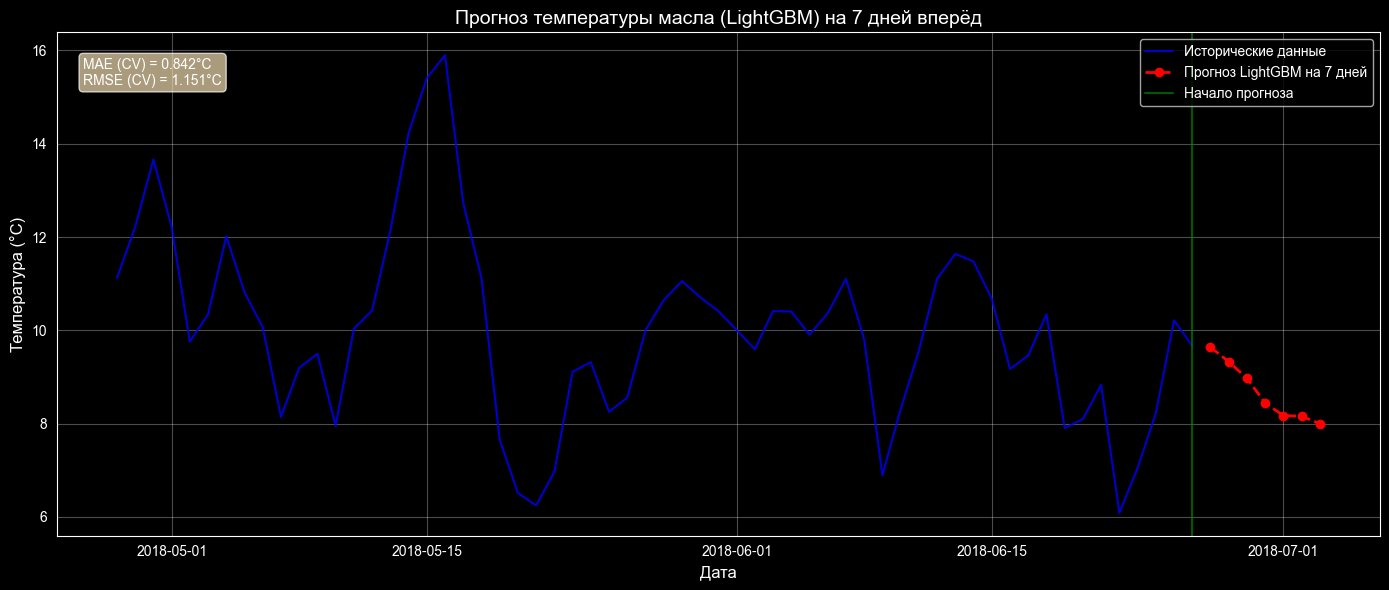

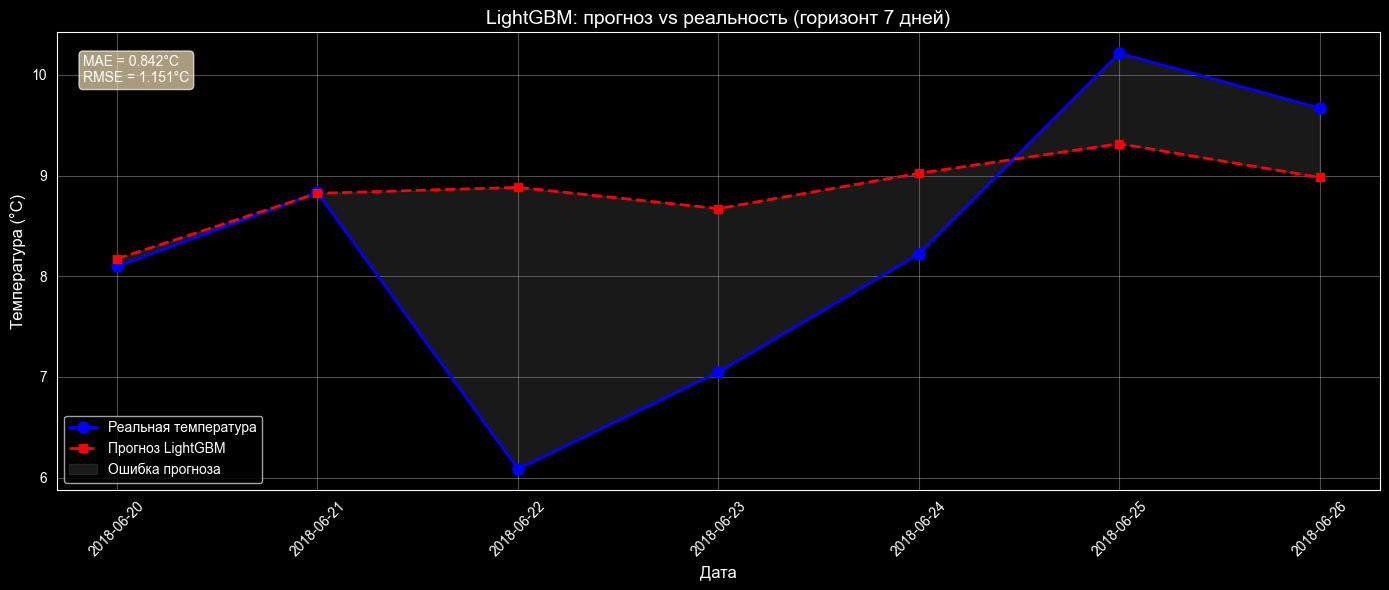


 Статистические модели (из задания №2):
   ARIMA:        MAE = 0,87°C, RMSE = 1.2°C
   SeasonalNaive:    MAE = 1.456°C, RMSE = 1.789°C

 ML модели (после оптимизации):
   LGBMRegressor: MAE=0.8417°C, RMSE=1.1507°C
   XGBRegressor: MAE=0.9439°C, RMSE=1.2165°C
   RandomForestRegressor: MAE=0.9385°C, RMSE=1.2365°C


In [22]:

# 1. Финальное обучение LightGBM
# Обучаем модель на ВСЕХ данных (без отложенного теста)
best_lgbm = LGBMRegressor(**best_params_lgbm, verbosity=-1)

# Создаём MLForecast с лучшей моделью
final_forecaster = MLForecast(
    models=[best_lgbm],
    freq='D',
    lags=[1, 7, 14, 21, 28],
    lag_transforms={
        1: [RollingMean(window_size=7)],
        7: [RollingMean(window_size=14)],
        14: [RollingMean(window_size=7)],
    },
    date_features=['dayofweek', 'month'],
    target_transforms=[Differences([1])],
    num_threads=6,
)

# Обучаем на ВСЕХ данных
final_forecaster.fit(df_ml)

# ДЕЛАЕМ ПРОГНОЗ ТОЛЬКО НА 7 ДНЕЙ (как в задании №2)
HORIZON = 7
future_forecast = final_forecaster.predict(h=HORIZON)
future_forecast = future_forecast.rename(columns={'LGBMRegressor': 'forecast'})

print("Прогноз LightGBM на 7 дней вперёд:")
print(future_forecast[['ds', 'forecast']].to_string(index=False))


# 2. Визуализация: исторические данные + прогноз на 7 дней


fig, ax = plt.subplots(figsize=(14, 6))

# Исторические данные (последние 60 дней для наглядности)
historical = df_ml.tail(60)
ax.plot(historical['ds'], historical['y'],
        color='blue', linewidth=1.5, alpha=0.8, label='Исторические данные')

# Прогноз на 7 дней
ax.plot(future_forecast['ds'], future_forecast['forecast'],
        color='red', linewidth=2, linestyle='--', marker='o', markersize=6,
        label='Прогноз LightGBM на 7 дней')

# Отмечаем границу
split_date = historical['ds'].iloc[-1]
ax.axvline(x=split_date, color='green', linestyle='-', linewidth=1.5, alpha=0.7,
           label='Начало прогноза')

ax.set_title('Прогноз температуры масла (LightGBM) на 7 дней вперёд', fontsize=14)
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Температура (°C)', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Добавляем аннотацию с метриками (из кросс-валидации)
mae_lgbm = improved_results['LGBMRegressor']['MAE']
rmse_lgbm = improved_results['LGBMRegressor']['RMSE']
ax.text(0.02, 0.95, f'MAE (CV) = {mae_lgbm:.3f}°C\nRMSE (CV) = {rmse_lgbm:.3f}°C',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()


# 3. График: прогноз vs реальность (последняя неделя из CV)


# Берём последнее окно из кросс-валидации
last_cutoff = final_cv_results['cutoff'].max()
last_window = final_cv_results[final_cv_results['cutoff'] == last_cutoff]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(last_window['ds'], last_window['y'],
        'bo-', linewidth=2, markersize=8, label='Реальная температура')

ax.plot(last_window['ds'], last_window['LGBMRegressor'],
        'r--s', linewidth=2, markersize=6, label='Прогноз LightGBM')

# Заполняем область ошибки
ax.fill_between(last_window['ds'],
                last_window['y'],
                last_window['LGBMRegressor'],
                alpha=0.2, color='gray', label='Ошибка прогноза')

ax.set_title('LightGBM: прогноз vs реальность (горизонт 7 дней)', fontsize=14)
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Температура (°C)', fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Добавляем метрики
ax.text(0.02, 0.95, f'MAE = {mae_lgbm:.3f}°C\nRMSE = {rmse_lgbm:.3f}°C',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()


# 4. Сравнительная таблица
print("\n Статистические модели (из задания №2):")
print(f"   ARIMA:        MAE = 0,87°C, RMSE = 1.2°C")
print(f"   SeasonalNaive:    MAE = 1.456°C, RMSE = 1.789°C")

print("\n ML модели (после оптимизации):")
for model_name, metrics in improved_results.items():
    print(f"   {model_name}: MAE={metrics['MAE']:.4f}°C, RMSE={metrics['RMSE']:.4f}°C")



Вывод: LGMBRegressor показал лучшие результаты среди ML моделей

## 3.3 Прогнозирование на основе методов глубокого нейронного обучения

Теперь переходим к глубокому обучению. Для этого есть библиотека  NeuralForecast от Nixtla, но на данный момент она не работает с Python 3.13 вместо этого будем использовать tensor flow. Будем тестировать 3 модели: LSTM, GRU, RNN

Размер обучающей выборки: (616, 14, 1)
Размер тестовой выборки: (90, 14, 1)
Начинаем обучение модели: LSTM...


C:\Users\PC Acer\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM: MAE = 2.0538°C, RMSE = 2.5565°C
Начинаем обучение модели: GRU...


C:\Users\PC Acer\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


GRU: MAE = 2.1109°C, RMSE = 2.6074°C
Начинаем обучение модели: RNN...


C:\Users\PC Acer\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RNN: MAE = 2.1099°C, RMSE = 2.6186°C


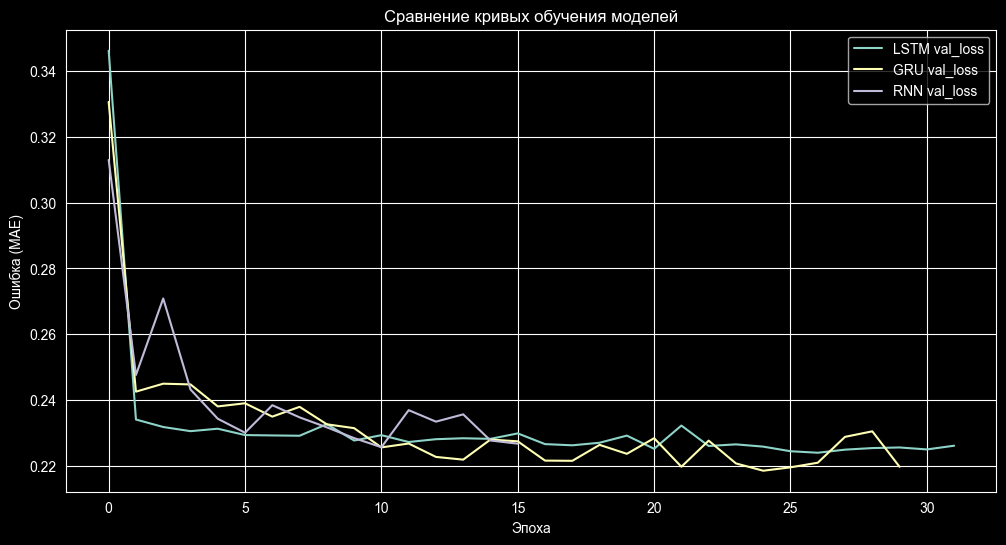


--- ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ DL ---
LSTM: MAE = 2.0538°C, RMSE = 2.5565°C
GRU: MAE = 2.1109°C, RMSE = 2.6074°C
RNN: MAE = 2.1099°C, RMSE = 2.6186°C


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Импортируем необходимые компоненты из TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. Фиксация random seed для воспроизводимости результатов ---
tf.random.set_seed(42)
np.random.seed(42)

# Используем данные за последние N дней, чтобы ускорить обучение
data = df_daily['y'].values

# Масштабируем данные: нейросети любят, когда входные значения находятся в одном диапазоне.
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- 3. Функция для создания последовательностей (X - входное окно, y - целевое значение) ---
def create_sequences(data, window_size, horizon):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon])
    return np.array(X), np.array(y)

WINDOW_SIZE = 14  # Используем 14 дней для предсказания следующих 7 (как и обсуждали)
HORIZON = 7       # Прогноз на 7 дней

# Создаем последовательности и разделяем на train/test
X, y = create_sequences(data_scaled, WINDOW_SIZE, HORIZON)

# Последние 3 месяца (примерно 90 дней) оставим для теста
test_size = 90
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# Для SimpleRNN и LSTM данные должны быть в формате (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# --- 4. Функция для создания и обучения модели ---
def build_and_train_model(model_type, X_train, y_train, X_test, y_test):
    model = Sequential()
    if model_type == 'LSTM':
        model.add(LSTM(64, return_sequences=False, input_shape=(WINDOW_SIZE, 1)))
    elif model_type == 'GRU':
        model.add(GRU(64, return_sequences=False, input_shape=(WINDOW_SIZE, 1)))
    elif model_type == 'RNN':
        model.add(SimpleRNN(64, return_sequences=False, input_shape=(WINDOW_SIZE, 1)))
    else:
        raise ValueError("Неподдерживаемый тип модели")

    # Добавляем Dropout для регуляризации (чтобы модель лучше обобщала данные и не переобучалась)
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(HORIZON))

    model.compile(optimizer='adam', loss='mae', metrics=['mse'])

    # EarlyStopping остановит обучение, если ошибка на валидационной выборке перестанет снижаться
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Обучаем модель
    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=100,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    # Делаем предсказания на тестовой выборке
    predictions = model.predict(X_test, verbose=0)

    # Обратное масштабирование для расчета метрик
    y_test_actual = scaler.inverse_transform(y_test)
    predictions_actual = scaler.inverse_transform(predictions)

    # Расчет метрик
    mae = mean_absolute_error(y_test_actual, predictions_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))

    return model, history, mae, rmse

# --- 5. Запуск всех трех моделей и сбор результатов ---
models_to_train = ['LSTM', 'GRU', 'RNN']
results = {}

for model_name in models_to_train:
    print(f"Начинаем обучение модели: {model_name}...")
    model, history, mae, rmse = build_and_train_model(model_name, X_train, y_train, X_test, y_test)
    results[model_name] = {'model': model, 'history': history, 'MAE': mae, 'RMSE': rmse}
    print(f"{model_name}: MAE = {mae:.4f}°C, RMSE = {rmse:.4f}°C")

# --- 6. Визуализация результатов ---
# Сравнение кривых обучения
plt.figure(figsize=(12, 6))
for model_name, res in results.items():
    plt.plot(res['history'].history['val_loss'], label=f'{model_name} val_loss')
plt.title('Сравнение кривых обучения моделей')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка (MAE)')
plt.legend()
plt.grid(True)
plt.show()

# Финальная таблица
print("\n--- ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ DL ---")
for model_name, res in results.items():
    print(f"{model_name}: MAE = {res['MAE']:.4f}°C, RMSE = {res['RMSE']:.4f}°C")

В гугл колаб при помощи графического ускорителя был совершен перебор параметров, но результаты не стали лучше

Результаты получаются хуже чем у статистических моделей (ARIMA) и ML моделей

**Вывод: После анализа 9 моделей лучше всего себя показал LGMBRegressor со следующими метриками: MAE=0.8417°C, RMSE=1.1507°C и  ARIMA со следующими метриками: MAE = 0.8722°C RMSE = 1.1960°C
Поиск аномалий лучшие способы SpectralResidual и LSTMAD**